In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_dataset.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


## Check types of data 

In [3]:
print(df.dtypes)

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object


## Drop irrelevant columns (Latitude, Longitude)

In [4]:
df = df.drop(["Latitude", "Longtitude"], axis=1)
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


## Rename columns City Code to City & Order Priority Code to Order Priority

In [5]:
df = df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
})

print(df.columns)

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')


## Check duplicate rows 

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6


## Drop duplicate records

In [7]:
df = df.drop_duplicates()

## Check missing and null values 

In [8]:
print(df.isnull().sum())

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64


## Fill missing sales value by their median

In [11]:
median_total = df["total"].median()
df["total"] = df["total"].fillna(median_total)

## Top 5 Best Selling Products

In [13]:
top_products = df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)
top_products

product
Watch         256
Mobile        230
Headphones    227
Bag           189
Shoes         188
Name: quantity, dtype: int64

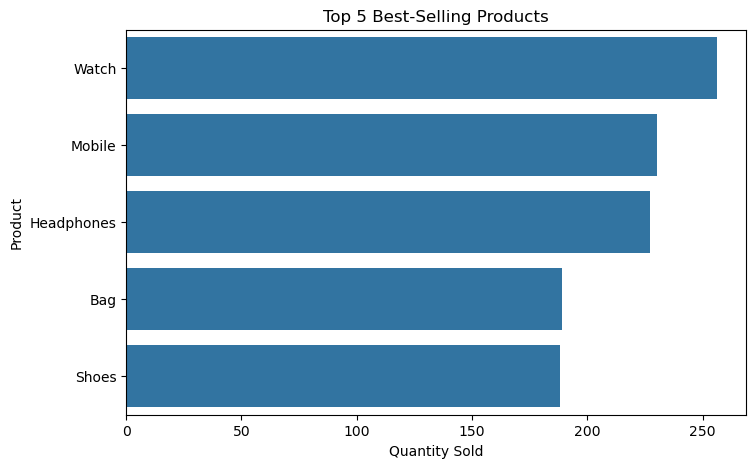

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 5 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

## Payment Method Distribution

In [15]:
payment_counts = df["payment_method"].value_counts()
payment_counts

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

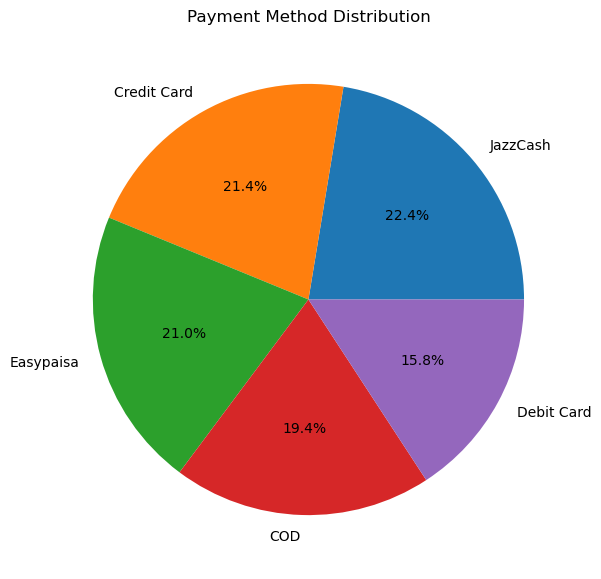

In [16]:
plt.figure(figsize=(7,7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.show()

## Month-wise Sales

In [17]:
monthly_sales = df.groupby("Month")["total"].sum()
monthly_sales

Month
April        6275753.74
August       2557288.54
December     3952563.75
February     5545040.22
January      6238414.59
July         2688475.62
June         2860920.11
March        6711119.66
May          5909845.92
November     2805153.37
October      3139444.82
September    2515916.08
Name: total, dtype: float64

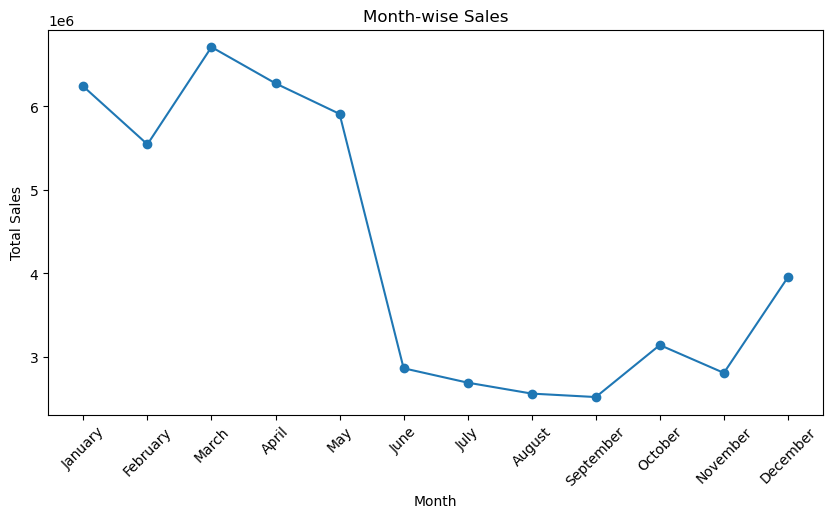

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

## Show City wise sales

In [20]:
city_names = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].map(city_names)

print(df["City"].value_counts())

City
Lahore        140
Quetta         97
Islamabad      77
Peshawar       71
Faisalabad     52
Karachi        48
Name: count, dtype: int64


In [21]:
city_sales = df.groupby("City")["total"].sum().sort_values()

print(city_sales)

City
Karachi        5060916.14
Peshawar       6194016.19
Faisalabad     6318998.97
Islamabad      8028811.58
Quetta         9488620.43
Lahore        14665005.16
Name: total, dtype: float64


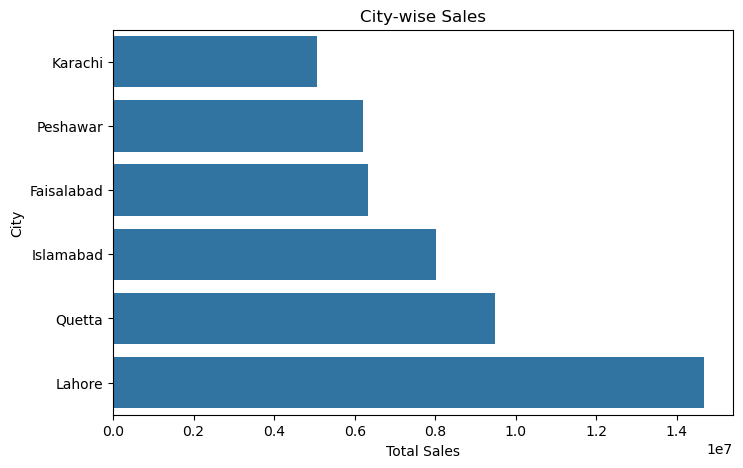

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

## Show monthly Sales by Category 

In [23]:
monthly_category_sales = df.groupby(
    ["Month", "category"]
)["total"].sum().unstack()

print(monthly_category_sales)

category   Accessories  Electronics     Fashion
Month                                          
April       2387980.38   2265079.20  1622694.16
August       521529.94    881950.11  1153808.49
December    1005459.07   1460885.05  1486219.63
February    1178881.69   1929360.80  2436797.73
January     2745729.82   1855039.15  1637645.62
July         961408.72   1218489.97   508576.93
June        1421673.13    657353.10   781893.88
March       2749630.71   2457415.74  1504073.21
May         1240740.21   2352232.89  2316872.82
November     739060.88    991960.56  1074131.93
October      496080.70   1911295.72   732068.40
September    849152.91    952931.97   713831.20


In [24]:
monthly_category_sales = monthly_category_sales.reindex(month_order)

print(monthly_category_sales)

category   Accessories  Electronics     Fashion
Month                                          
January     2745729.82   1855039.15  1637645.62
February    1178881.69   1929360.80  2436797.73
March       2749630.71   2457415.74  1504073.21
April       2387980.38   2265079.20  1622694.16
May         1240740.21   2352232.89  2316872.82
June        1421673.13    657353.10   781893.88
July         961408.72   1218489.97   508576.93
August       521529.94    881950.11  1153808.49
September    849152.91    952931.97   713831.20
October      496080.70   1911295.72   732068.40
November     739060.88    991960.56  1074131.93
December    1005459.07   1460885.05  1486219.63


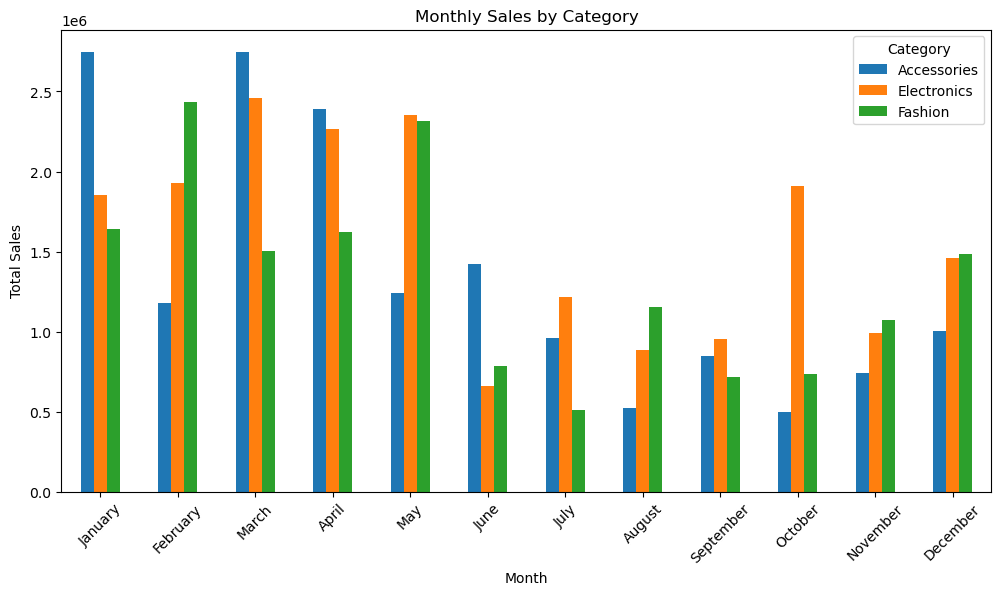

In [25]:
monthly_category_sales.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.legend(title="Category")

plt.show()